## Title
Interpretacion del modelo seleccionado
### By:
Dovaribi Carupia Yagari

### Date:
2026-08-21

### Description:

# Requerimiento

Analizar las características del modelo obtenido, con el fin de tener un listado de pruebas y experimentos que se van a realizar en la siguiente iteración.

> Tomar como ejemplo los pasos de: <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/7-model_interpretation/>

En este proceso se incluye :

- Interpretar el modelo seleccionado.
- Identificar los atributos más importantes.
- Realizar el análisis de Learning curve.
- Obtener gráficas de escalabilidad con tiempo de entrenamiento y score.
- Analizar las consecuencias de las malas predicciones.
- Identificar qué tipo de errores comete el modelo y a qué se deben.
- Considerar outliers, desbalance, errores de ingreso y encoders.

# Entregables

Notebook con la interpretación y el análisis del modelo entrenado en formato `.joblib`. Se requiere revisión y validación del CI/CD antes del Pull Request.

## 1. Alcance y prevención de data leakage

Este notebook interpreta el pipeline ya entrenado en el notebook 06. No vuelve a ajustar el modelo, no recalcula imputaciones y no modifica el archivo `.joblib`.

El conjunto de test se utiliza únicamente para describir el comportamiento final y los errores del modelo. Las learning curves se calculan solo con train y no se usarán para cambiar hiperparámetros en este notebook.

## 2. Carga del artifact y reproducción del split

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import load
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, learning_curve, train_test_split

PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model.preprocessing import load_supervised_data  # noqa: E402

In [2]:
ARTIFACT_PATH = PROJECT_ROOT / "models" / "modelo_final.joblib"
DATA_PATH = PROJECT_ROOT / "data" / "02_intermediate" / "pacientes_higado_exploracion.parquet"

artifact = load(ARTIFACT_PATH)
model_pipeline = artifact["pipeline"]
selected_model_name = artifact["model_name"]

X, y = load_supervised_data(DATA_PATH)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Modelo cargado: {selected_model_name}")
print(f"Artifact: {ARTIFACT_PATH}")
print(f"Train: {X_train.shape}; Test: {X_test.shape}")
print(f"Métricas guardadas: {artifact.get('test_metrics', {})}")

Modelo cargado: logistic_regression
Artifact: C:\Users\dova1\Pacientes-problemas-higado-proyecto-data-Science\models\modelo_final.joblib
Train: (470, 10); Test: (118, 10)
Métricas guardadas: {'accuracy': 0.6864406779661016, 'balanced_accuracy': 0.7359943977591037, 'precision_disease': 0.9122807017543859, 'recall_disease': 0.6190476190476191, 'f1_disease': 0.7375886524822695, 'roc_auc': 0.8147759103641457, 'average_precision': 0.9160068650682871, 'specificity': 0.8529411764705882}


## 3. Interpretación global de los coeficientes

El modelo seleccionado es una regresión logística. Sus coeficientes se interpretan en el espacio transformado: un coeficiente positivo aumenta el score hacia la clase enfermedad y uno negativo lo reduce. Como las variables numéricas fueron escaladas, la magnitud permite comparar aproximadamente sus efectos por unidad transformada.

In [3]:
model = model_pipeline.named_steps["model"]
features_pipeline = model_pipeline.named_steps["features"]
feature_names = features_pipeline.get_feature_names_out()
coefficients = model.coef_[0]

coefficient_table = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Coefficient": coefficients,
            "Odds_ratio_per_transformed_unit": np.exp(coefficients),
        }
    )
    .assign(Absolute_coefficient=lambda table: table["Coefficient"].abs())
    .sort_values("Absolute_coefficient", ascending=False)
)
display(coefficient_table.round(4))

,Feature,Coefficient,Odds_ratio_per_transformed_unit,Absolute_coefficient
3,Alamine_Aminotransferase,0.2228,1.2495,0.2228
1,Direct_Bilirubin,0.1884,1.2073,0.1884
0,Total_Bilirubin,0.1876,1.2063,0.1876
2,Alkaline_Phosphotase,0.1783,1.1952,0.1783
4,Aspartate_Aminotransferase,0.1692,1.1844,0.1692
7,Age,0.1292,1.1379,0.1292
5,Direct_to_Total_Bilirubin,0.1247,1.1328,0.1247
10,Albumin_and_Globulin_Ratio,-0.1157,0.8907,0.1157
9,Albumin,-0.0878,0.9159,0.0878
8,Total_Protiens,0.0229,1.0232,0.0229


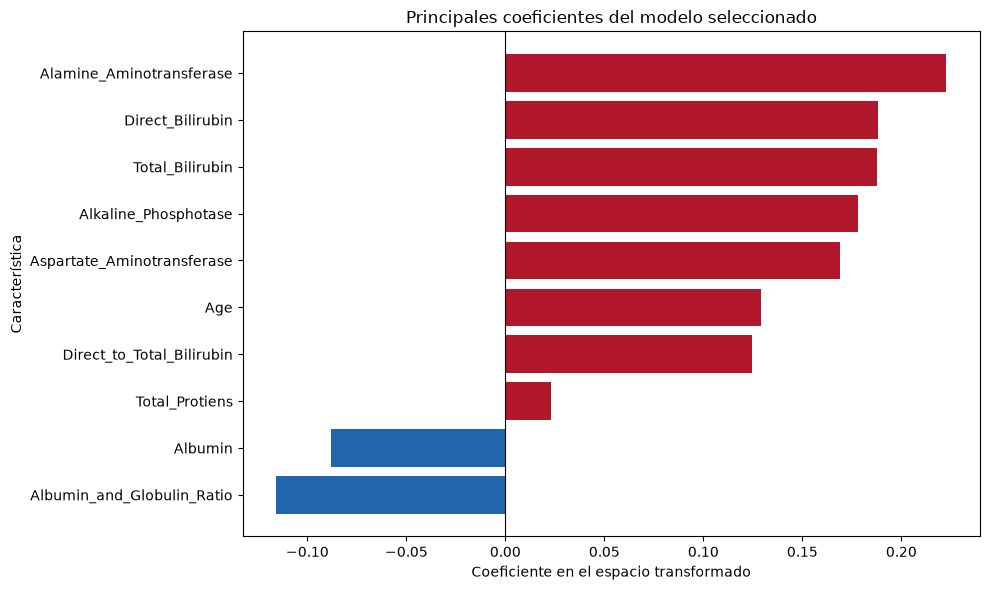

In [4]:
top_coefficients = coefficient_table.head(10).sort_values("Coefficient")
colors = np.where(top_coefficients["Coefficient"] >= 0, "#b2182b", "#2166ac")

plt.figure(figsize=(10, 6))
plt.barh(top_coefficients["Feature"], top_coefficients["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Principales coeficientes del modelo seleccionado")
plt.xlabel("Coeficiente en el espacio transformado")
plt.ylabel("Característica")
plt.tight_layout()
plt.show()

### Lectura de los coeficientes

- Los coeficientes positivos empujan la predicción hacia enfermedad hepática.
- Los coeficientes negativos empujan la predicción hacia ausencia de enfermedad.
- Las variables categóricas representan una categoría respecto a la codificación aprendida por One-Hot Encoder.
- Un coeficiente no demuestra causalidad clínica. Es una asociación condicionada por las demás variables y por las transformaciones del pipeline.
- Las razones clínicas derivadas deben validarse con expertos antes de interpretarse como reglas médicas.

## 4. Interpretación local mediante contribuciones

Para una regresión logística, la contribución aproximada de cada característica al score lineal es `valor_transformado * coeficiente`. La suma de contribuciones más el intercepto corresponde al `decision_function` del modelo.

In [5]:
X_test_transformed = features_pipeline.transform(X_test)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

contributions = X_test_transformed.mul(coefficients, axis=1)
decision_scores = model_pipeline.decision_function(X_test)
contribution_totals = contributions.sum(axis=1) + model.intercept_[0]

contribution_check = pd.DataFrame(
    {
        "Decision_score": decision_scores,
        "Contribution_sum": contribution_totals,
        "Absolute_difference": np.abs(decision_scores - contribution_totals),
    },
    index=X_test.index,
)
display(contribution_check.head().round(8))
print(f"Máxima diferencia de reconstrucción: {contribution_check['Absolute_difference'].max():.8f}")

,Decision_score,Contribution_sum,Absolute_difference
181,0.581569,0.581569,0.0
127,0.614761,0.614761,0.0
463,-0.766164,-0.766164,0.0
385,-0.506415,-0.506415,0.0
631,0.967178,0.967178,0.0


Máxima diferencia de reconstrucción: 0.00000000


In [6]:
def top_contributions(row_index: int, count: int = 6) -> pd.DataFrame:
    row_contributions = contributions.loc[row_index].sort_values()
    selected = pd.concat([row_contributions.head(count // 2), row_contributions.tail(count // 2)])
    return selected.rename("Contribution").to_frame()


example_index = X_test.index[0]
print(f"Contribuciones para la observación {example_index}:")
display(top_contributions(example_index).round(4))

Contribuciones para la observación 181:


,Contribution
Total_Protiens,-0.0574
Albumin_and_Globulin_Ratio,-0.0260
Alamine_Aminotransferase,-0.0203
Age,0.1498
Direct_Bilirubin,0.1597
Total_Bilirubin,0.1672


## 5. Learning curve y escalabilidad

La curva se calcula usando únicamente train. El pipeline se clona y ajusta dentro de cada fold, sin consultar el test ni modificar el artifact guardado.

,Train_size,Train_score_mean,Validation_score_mean,Fit_time_mean_seconds
0,75,0.7149,0.6884,0.2115
1,150,0.6899,0.6902,0.2104
2,225,0.6960,0.6959,0.1984
3,300,0.7118,0.6909,0.1950
4,376,0.7142,0.7076,0.1900


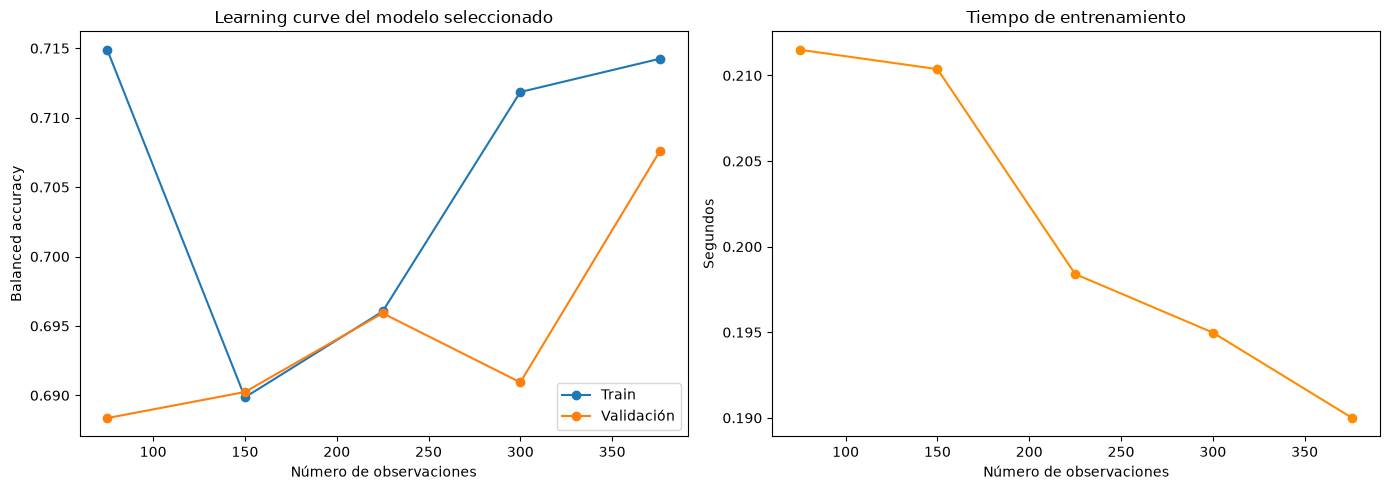

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, validation_scores, fit_times, _ = learning_curve(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring="balanced_accuracy",
    return_times=True,
    n_jobs=-1,
)

learning_summary = pd.DataFrame(
    {
        "Train_size": train_sizes,
        "Train_score_mean": train_scores.mean(axis=1),
        "Validation_score_mean": validation_scores.mean(axis=1),
        "Fit_time_mean_seconds": fit_times.mean(axis=1),
    }
).round(4)
display(learning_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train")
axes[0].plot(train_sizes, validation_scores.mean(axis=1), marker="o", label="Validación")
axes[0].set_title("Learning curve del modelo seleccionado")
axes[0].set_xlabel("Número de observaciones")
axes[0].set_ylabel("Balanced accuracy")
axes[0].legend()

axes[1].plot(train_sizes, fit_times.mean(axis=1), marker="o", color="darkorange")
axes[1].set_title("Tiempo de entrenamiento")
axes[1].set_xlabel("Número de observaciones")
axes[1].set_ylabel("Segundos")

plt.tight_layout()
plt.show()

## 6. Análisis de errores

Se clasifica cada predicción del test en verdadero positivo, verdadero negativo, falso positivo o falso negativo. Los falsos negativos son especialmente importantes porque representan pacientes con enfermedad a quienes el modelo no identifica.

In [8]:
test_predictions = model_pipeline.predict(X_test)
test_probabilities = model_pipeline.predict_proba(X_test)[:, 1]

error_analysis = X_test.copy()
error_analysis["Actual"] = y_test
error_analysis["Predicted"] = test_predictions
error_analysis["Disease_probability"] = test_probabilities
error_analysis["Error_type"] = np.select(
    [
        (y_test == 1) & (test_predictions == 1),
        (y_test == 0) & (test_predictions == 0),
        (y_test == 0) & (test_predictions == 1),
        (y_test == 1) & (test_predictions == 0),
    ],
    ["True positive", "True negative", "False positive", "False negative"],
    default="Unknown",
)

display(error_analysis["Error_type"].value_counts().to_frame("Count"))
display(
    error_analysis[
        error_analysis["Error_type"].isin(["False positive", "False negative"])
    ].sort_values("Disease_probability")
)

,Count
Error_type,
True positive,52
False negative,32
True negative,29
False positive,5


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Actual,Predicted,Disease_probability,Error_type
81,29,Male,1.0,0.3,75.0,25.0,26.0,5.1,2.9,1.30,1,0,0.283728,False negative
286,34,Female,0.8,0.2,192.0,15.0,12.0,8.6,4.7,1.20,1,0,0.287231,False negative
267,43,Female,0.9,0.3,140.0,12.0,29.0,7.4,3.5,1.80,1,0,0.296879,False negative
463,25,Male,0.8,0.1,130.0,23.0,42.0,8.0,4.0,1.00,1,0,0.317309,False negative
148,50,Male,0.9,0.2,202.0,20.0,26.0,7.2,4.5,1.66,1,0,0.343057,False negative
84,32,Male,0.6,0.1,237.0,45.0,31.0,7.5,4.3,1.34,1,0,0.369973,False negative
556,51,Male,0.7,0.1,180.0,25.0,27.0,6.1,3.1,1.00,1,0,0.375802,False negative
385,50,Male,0.8,0.2,152.0,29.0,30.0,7.4,4.1,1.30,1,0,0.376034,False negative
242,29,Female,0.8,0.2,205.0,30.0,23.0,8.2,4.1,1.00,1,0,0.384136,False negative
219,37,Male,0.8,0.2,125.0,41.0,39.0,6.4,3.4,1.10,1,0,0.388504,False negative


                precision    recall  f1-score   support

Sin enfermedad       0.48      0.85      0.61        34
    Enfermedad       0.91      0.62      0.74        84

      accuracy                           0.69       118
     macro avg       0.69      0.74      0.67       118
  weighted avg       0.79      0.69      0.70       118



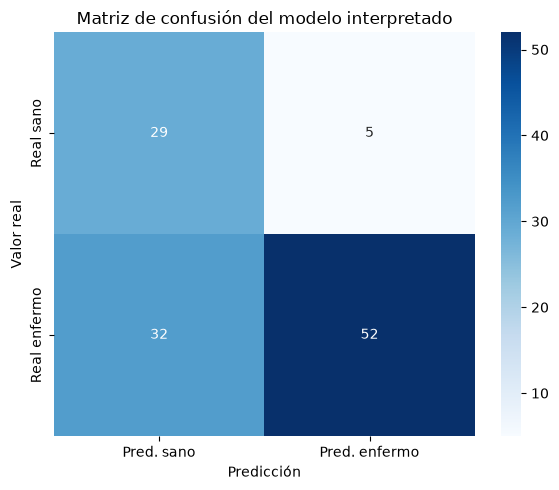

In [9]:
confusion = confusion_matrix(y_test, test_predictions, labels=[0, 1])
print(
    classification_report(
        y_test, test_predictions, target_names=["Sin enfermedad", "Enfermedad"], zero_division=0
    )
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred. sano", "Pred. enfermo"],
    yticklabels=["Real sano", "Real enfermo"],
)
plt.title("Matriz de confusión del modelo interpretado")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

## 7. Consecuencias y posibles causas de los errores

- **Falsos negativos:** son el error clínicamente más grave porque pueden retrasar la atención de un paciente enfermo. Deben investigarse antes de cualquier uso real.
- **Falsos positivos:** pueden producir exámenes, derivaciones o seguimientos adicionales, aunque son preferibles a un falso negativo si el objetivo principal es sensibilidad.
- **Valores atípicos:** las enzimas hepáticas tienen colas largas; el escalado robusto los conserva, pero la regresión logística puede no representar bien patrones extremos.
- **Desbalance:** el uso de `class_weight="balanced"` modifica la penalización, pero no elimina la necesidad de revisar Recall y especificidad.
- **Valores faltantes:** la imputación puede ocultar diferencias clínicas si los datos faltan de manera no aleatoria.
- **Encoding:** `Gender` se codifica dentro del pipeline; categorías nuevas se ignoran, por lo que deben monitorearse en producción.
- **Calidad de medición:** unidades, errores de digitación, rangos de laboratorio y diferencias entre centros pueden explicar parte de los errores.

Las explicaciones observadas son hipótesis para la siguiente iteración, no pruebas de causalidad.

## 8. Experimentos propuestos para la siguiente iteración

- Evaluar umbrales de decisión distintos de 0.5 usando únicamente train y validación cruzada, priorizando Recall sin perder demasiada especificidad.
- Calibrar probabilidades antes de presentarlas como riesgo clínico.
- Comparar regresión logística con modelos no lineales y revisar sus errores por subgrupos de edad y género.
- Hacer un estudio de ablación de las razones clínicas derivadas y de cada transformación.
- Revisar los duplicados con el origen de los datos y analizar la sensibilidad del modelo a outliers.
- Incorporar unidades, rangos de referencia, fechas, método diagnóstico y antecedentes clínicos si están disponibles.
- Realizar validación externa y monitorear cambios de distribución antes del despliegue en Streamlit.